In [1]:
#Q1: What is the overall month-over-month trend for Sales and Profit? Is the business growing?

In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv(r'C:\Users\Marcus\Desktop\python pandas\superstore_data\version_control\superstore_clean.csv')

df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,31518,CA-2012-169397,2012-12-24,27-12-2012,First Class,JB-15925,Joni Blumstein,Consumer,Dublin,Ohio,...,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,19.7760,4,0.70,-13.84,0.79,Medium
1,6224,US-2011-144729,2011-07-21,24-07-2011,First Class,SS-20140,Saphhira Shifley,Corporate,San Miguelito,Panama,...,OFF-FA-10002247,Office Supplies,Fasteners,"Oic Paper Clips, Bulk Pack",11.5440,2,0.40,-5.22,0.97,Medium
2,15333,IT-2014-4749412,2014-09-18,23-09-2014,Standard Class,MB-18085,Mick Brown,Unknown,Birmingham,England,...,OFF-AR-10003113,Office Supplies,Art,"Binney & Smith Pens, Blue",29.8500,5,0.50,-4.80,3.71,Medium
3,49259,NI-2013-4420,2013-04-10,10/10/2013,Standard Class,MP-7965,Michael Paige,Corporate,Lagos,Lagos,...,OFF-AVE-10004512,Office Supplies,Binders,"Avery Hole Reinforcements, Economy",1.3230,1,0.70,-3.09,0.06,Medium
4,24199,IN-2014-14423,2014-10-29,30-10-2014,First Class,DL-12925,Daniel Lacy,Consumer,Kendari,Sulawesi Tenggara,...,FUR-FU-10002362,Furnitures,Furnishings,"Advantus Door Stop, Black",131.4876,4,0.27,25.17,0.00,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,17526,ES-2014-2057259,2014-08-02,5/8/2014,First Class,PB-19150,Philip Brown,Consumer,Cagnes-Sur-Mer,Provence-Alpes-Cote D'Azur,...,OFF-PA-10002616,Office Supplies,Paper,"Green Bar Parchment Paper, Multicolor",108.5400,6,0.00,34.56,11.76,Medium
51366,36055,CA-2011-121573,2011-11-03,"Jul 11, 2011",Standard Class,SG-20605,Speros Goranitis,Consumer,New York City,New York,...,TEC-PH-10000984,Technology,Phones,Panasonic Kx-Tg9471B,783.9600,4,0.00,219.51,64.42,High
51367,43576,TU-2011-9190,2011-12-23,28-12-2011,Second Class,CM-1830,Cari Macintyre,Corporate,Corum,Corum,...,OFF-KIT-10002357,Office Supplies,Appliances,"Kitchenaid Blender, White",39.8400,1,0.60,-12.96,5.84,Medium
51368,22403,IN-2013-35388,2013-08-07,11/8/2013,Standard Class,IM-15055,Unknown,Consumer,Jakarta,Jakarta,...,OFF-AR-10000058,Office Supplies,Art,"Stanley Canvas, Water Color",38.4345,1,0.27,3.66,2.96,Medium


In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51370 entries, 0 to 51369
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51370 non-null  int64         
 1   Order ID        51370 non-null  str           
 2   Order Date      51370 non-null  datetime64[us]
 3   Ship Date       51370 non-null  str           
 4   Ship Mode       51370 non-null  str           
 5   Customer ID     51370 non-null  str           
 6   Customer Name   51336 non-null  str           
 7   Segment         51370 non-null  str           
 8   City            51351 non-null  str           
 9   State           51339 non-null  str           
 10  Country         51370 non-null  str           
 11  Postal Code     51370 non-null  int64         
 12  Market          51370 non-null  str           
 13  Region          51370 non-null  str           
 14  Product ID      51370 non-null  str           
 15  Category     

In [5]:
df['Order Date'].dt.month

0        12
1         7
2         9
3         4
4        10
         ..
51365     8
51366    11
51367    12
51368     8
51369     9
Name: Order Date, Length: 51370, dtype: int32

In [6]:
monthly_sales_and_profit = df.groupby(
    [
        df['Order Date'].dt.year.rename('Year'),
        df['Order Date'].dt.month.rename('Month')
    ]
)[[
    'Sales',
    'Profit'
    ]].agg('sum').round(2)

monthly_sales_and_profit

Sales    Profit
Year Month                     
2011 1      107236.58   8990.02
     2       99584.12  13316.94
     3      149148.53  15554.38
     4      123240.17  15673.65
     5      153503.64  13684.18
     6      213167.71  23848.08
     7      123463.50   8083.63
     8      203519.58  23022.77
     9      289949.95  36782.33
     10     195831.49  24514.55
     11     278066.95  27238.85
     12     325930.94  39811.22
2012 1      135140.32  10045.94
     2      113699.47  15343.47
     3      164031.23  16691.69
     4      165443.77  17427.34
     5      201516.25  27485.93
     6      258578.01  34494.14
     7      155031.83  18968.60
     8      304041.39  43618.74
     9      280693.95  26101.69
     10     260348.40  36314.39
     11     306074.46  28885.64
     12     335713.48  32779.79
2013 1      203887.10  29375.16
     2      177366.18  25573.01
     3      197963.23  24393.53
     4      190105.50  19598.93
     5      263675.59  27673.63
     6      378058.17  43970.36
     7      230160.15  28860.14
     8      323749.69  31873.06
     9      374361.95  37436.96
     10     299171.28  41553.34
     11     374078.87  48588.12
     12     401836.11  50253.17
2014 1      249319.91  29610.75
     2      189131.13  19203.88
     3      268287.32  40806.84
     4      250444.15  24043.22
     5      297082.34  29645.23
     6      409928.26  46333.23
     7      266624.48  27510.41
     8      459382.29  58370.48
     9      458947.33  62305.57
     10     422315.11  58284.73
     11     538245.49  63283.18
     12     498179.37  43370.66

In [7]:
sales_monthly_lag = monthly_sales_and_profit['Sales'].shift(1)
sales_monthly_lag

Year  Month
2011  1              NaN
      2        107236.58
      3         99584.12
      4        149148.53
      5        123240.17
      6        153503.64
      7        213167.71
      8        123463.50
      9        203519.58
      10       289949.95
      11       195831.49
      12       278066.95
2012  1        325930.94
      2        135140.32
      3        113699.47
      4        164031.23
      5        165443.77
      6        201516.25
      7        258578.01
      8        155031.83
      9        304041.39
      10       280693.95
      11       260348.40
      12       306074.46
2013  1        335713.48
      2        203887.10
      3        177366.18
      4        197963.23
      5        190105.50
      6        263675.59
      7        378058.17
      8        230160.15
      9        323749.69
      10       374361.95
      11       299171.28
      12       374078.87
2014  1        401836.11
      2        249319.91
      3        189131.13
      4      

In [8]:
mom_growth = (monthly_sales_and_profit['Sales'] - sales_monthly_lag) / sales_monthly_lag
mom_growth

Year  Month
2011  1             NaN
      2       -0.071361
      3        0.497714
      4       -0.173708
      5        0.245565
      6        0.388682
      7       -0.420815
      8        0.648419
      9        0.424678
      10      -0.324602
      11       0.419930
      12       0.172131
2012  1       -0.585371
      2       -0.158656
      3        0.442674
      4        0.008611
      5        0.218035
      6        0.283162
      7       -0.400445
      8        0.961155
      9       -0.076790
      10      -0.072483
      11       0.175634
      12       0.096836
2013  1       -0.392675
      2       -0.130076
      3        0.116127
      4       -0.039693
      5        0.386996
      6        0.433800
      7       -0.391204
      8        0.406628
      9        0.156331
      10      -0.200850
      11       0.250384
      12       0.074202
2014  1       -0.379548
      2       -0.241412
      3        0.418525
      4       -0.066508
      5        0.186222
    

In [9]:
mom_pct = (mom_growth * 100).round(2)
mom_pct

Year  Month
2011  1          NaN
      2        -7.14
      3        49.77
      4       -17.37
      5        24.56
      6        38.87
      7       -42.08
      8        64.84
      9        42.47
      10      -32.46
      11       41.99
      12       17.21
2012  1       -58.54
      2       -15.87
      3        44.27
      4         0.86
      5        21.80
      6        28.32
      7       -40.04
      8        96.12
      9        -7.68
      10       -7.25
      11       17.56
      12        9.68
2013  1       -39.27
      2       -13.01
      3        11.61
      4        -3.97
      5        38.70
      6        43.38
      7       -39.12
      8        40.66
      9        15.63
      10      -20.09
      11       25.04
      12        7.42
2014  1       -37.95
      2       -24.14
      3        41.85
      4        -6.65
      5        18.62
      6        37.98
      7       -34.96
      8        72.30
      9        -0.09
      10       -7.98
      11       27.45
 

In [10]:
monthly_sales_and_profit['Month_Over_Month_Growth'] = mom_growth

In [11]:
monthly_sales_and_profit['MoM_Growth_Pct'] = mom_pct

In [12]:
monthly_sales_and_profit

Sales    Profit  Month_Over_Month_Growth  MoM_Growth_Pct
Year Month                                                              
2011 1      107236.58   8990.02                      NaN             NaN
     2       99584.12  13316.94                -0.071361           -7.14
     3      149148.53  15554.38                 0.497714           49.77
     4      123240.17  15673.65                -0.173708          -17.37
     5      153503.64  13684.18                 0.245565           24.56
     6      213167.71  23848.08                 0.388682           38.87
     7      123463.50   8083.63                -0.420815          -42.08
     8      203519.58  23022.77                 0.648419           64.84
     9      289949.95  36782.33                 0.424678           42.47
     10     195831.49  24514.55                -0.324602          -32.46
     11     278066.95  27238.85                 0.419930           41.99
     12     325930.94  39811.22                 0.172131           17.21
2012 1      135140.32  10045.94                -0.585371          -58.54
     2      113699.47  15343.47                -0.158656          -15.87
     3      164031.23  16691.69                 0.442674           44.27
     4      165443.77  17427.34                 0.008611            0.86
     5      201516.25  27485.93                 0.218035           21.80
     6      258578.01  34494.14                 0.283162           28.32
     7      155031.83  18968.60                -0.400445          -40.04
     8      304041.39  43618.74                 0.961155           96.12
     9      280693.95  26101.69                -0.076790           -7.68
     10     260348.40  36314.39                -0.072483           -7.25
     11     306074.46  28885.64                 0.175634           17.56
     12     335713.48  32779.79                 0.096836            9.68
2013 1      203887.10  29375.16                -0.392675          -39.27
     2      177366.18  25573.01                -0.130076          -13.01
     3      197963.23  24393.53                 0.116127           11.61
     4      190105.50  19598.93                -0.039693           -3.97
     5      263675.59  27673.63                 0.386996           38.70
     6      378058.17  43970.36                 0.433800           43.38
     7      230160.15  28860.14                -0.391204          -39.12
     8      323749.69  31873.06                 0.406628           40.66
     9      374361.95  37436.96                 0.156331           15.63
     10     299171.28  41553.34                -0.200850          -20.09
     11     374078.87  48588.12                 0.250384           25.04
     12     401836.11  50253.17                 0.074202            7.42
2014 1      249319.91  29610.75                -0.379548          -37.95
     2      189131.13  19203.88                -0.241412          -24.14
     3      268287.32  40806.84                 0.418525           41.85
     4      250444.15  24043.22                -0.066508           -6.65
     5      297082.34  29645.23                 0.186222           18.62
     6      409928.26  46333.23                 0.379847           37.98
     7      266624.48  27510.41                -0.349583          -34.96
     8      459382.29  58370.48                 0.722956           72.30
     9      458947.33  62305.57                -0.000947           -0.09
     10     422315.11  58284.73                -0.079818           -7.98
     11     538245.49  63283.18                 0.274512           27.45
     12     498179.37  43370.66                -0.074438           -7.44

In [13]:
monthly_sales_and_profit.rename(columns={'Month_Over_Month_Growth':'Sales_MoM_Growth'}, inplace=True)

In [14]:
monthly_sales_and_profit.rename(columns={'MoM_Growth_Pct':'Sales_MoM_Pct'},inplace=True)

In [15]:
monthly_sales_and_profit

Sales    Profit  Sales_MoM_Growth  Sales_MoM_Pct
Year Month                                                      
2011 1      107236.58   8990.02               NaN            NaN
     2       99584.12  13316.94         -0.071361          -7.14
     3      149148.53  15554.38          0.497714          49.77
     4      123240.17  15673.65         -0.173708         -17.37
     5      153503.64  13684.18          0.245565          24.56
     6      213167.71  23848.08          0.388682          38.87
     7      123463.50   8083.63         -0.420815         -42.08
     8      203519.58  23022.77          0.648419          64.84
     9      289949.95  36782.33          0.424678          42.47
     10     195831.49  24514.55         -0.324602         -32.46
     11     278066.95  27238.85          0.419930          41.99
     12     325930.94  39811.22          0.172131          17.21
2012 1      135140.32  10045.94         -0.585371         -58.54
     2      113699.47  15343.47         -0.158656         -15.87
     3      164031.23  16691.69          0.442674          44.27
     4      165443.77  17427.34          0.008611           0.86
     5      201516.25  27485.93          0.218035          21.80
     6      258578.01  34494.14          0.283162          28.32
     7      155031.83  18968.60         -0.400445         -40.04
     8      304041.39  43618.74          0.961155          96.12
     9      280693.95  26101.69         -0.076790          -7.68
     10     260348.40  36314.39         -0.072483          -7.25
     11     306074.46  28885.64          0.175634          17.56
     12     335713.48  32779.79          0.096836           9.68
2013 1      203887.10  29375.16         -0.392675         -39.27
     2      177366.18  25573.01         -0.130076         -13.01
     3      197963.23  24393.53          0.116127          11.61
     4      190105.50  19598.93         -0.039693          -3.97
     5      263675.59  27673.63          0.386996          38.70
     6      378058.17  43970.36          0.433800          43.38
     7      230160.15  28860.14         -0.391204         -39.12
     8      323749.69  31873.06          0.406628          40.66
     9      374361.95  37436.96          0.156331          15.63
     10     299171.28  41553.34         -0.200850         -20.09
     11     374078.87  48588.12          0.250384          25.04
     12     401836.11  50253.17          0.074202           7.42
2014 1      249319.91  29610.75         -0.379548         -37.95
     2      189131.13  19203.88         -0.241412         -24.14
     3      268287.32  40806.84          0.418525          41.85
     4      250444.15  24043.22         -0.066508          -6.65
     5      297082.34  29645.23          0.186222          18.62
     6      409928.26  46333.23          0.379847          37.98
     7      266624.48  27510.41         -0.349583         -34.96
     8      459382.29  58370.48          0.722956          72.30
     9      458947.33  62305.57         -0.000947          -0.09
     10     422315.11  58284.73         -0.079818          -7.98
     11     538245.49  63283.18          0.274512          27.45
     12     498179.37  43370.66         -0.074438          -7.44

In [16]:
monthly_sales_and_profit.min().round(2)

Sales               99584.12
Profit               8083.63
Sales_MoM_Growth       -0.59
Sales_MoM_Pct         -58.54
dtype: float64

In [17]:
monthly_sales_and_profit.max().round(2)

Sales               538245.49
Profit               63283.18
Sales_MoM_Growth         0.96
Sales_MoM_Pct           96.12
dtype: float64

In [18]:
prev_monthly_profit = monthly_sales_and_profit['Profit'].shift(1)

In [19]:
profit_mom_growth = ((monthly_sales_and_profit['Profit'] - prev_monthly_profit) / prev_monthly_profit).round(2)

In [20]:
profit_mom_pct = profit_mom_growth * 100

In [21]:
monthly_sales_and_profit['Profit_MoM_Growth'] = profit_mom_growth
monthly_sales_and_profit['Profit_MoM_Pct'] = profit_mom_pct
monthly_sales_and_profit

Sales    Profit  Sales_MoM_Growth  Sales_MoM_Pct  \
Year Month                                                         
2011 1      107236.58   8990.02               NaN            NaN   
     2       99584.12  13316.94         -0.071361          -7.14   
     3      149148.53  15554.38          0.497714          49.77   
     4      123240.17  15673.65         -0.173708         -17.37   
     5      153503.64  13684.18          0.245565          24.56   
     6      213167.71  23848.08          0.388682          38.87   
     7      123463.50   8083.63         -0.420815         -42.08   
     8      203519.58  23022.77          0.648419          64.84   
     9      289949.95  36782.33          0.424678          42.47   
     10     195831.49  24514.55         -0.324602         -32.46   
     11     278066.95  27238.85          0.419930          41.99   
     12     325930.94  39811.22          0.172131          17.21   
2012 1      135140.32  10045.94         -0.585371         -58.54   
     2      113699.47  15343.47         -0.158656         -15.87   
     3      164031.23  16691.69          0.442674          44.27   
     4      165443.77  17427.34          0.008611           0.86   
     5      201516.25  27485.93          0.218035          21.80   
     6      258578.01  34494.14          0.283162          28.32   
     7      155031.83  18968.60         -0.400445         -40.04   
     8      304041.39  43618.74          0.961155          96.12   
     9      280693.95  26101.69         -0.076790          -7.68   
     10     260348.40  36314.39         -0.072483          -7.25   
     11     306074.46  28885.64          0.175634          17.56   
     12     335713.48  32779.79          0.096836           9.68   
2013 1      203887.10  29375.16         -0.392675         -39.27   
     2      177366.18  25573.01         -0.130076         -13.01   
     3      197963.23  24393.53          0.116127          11.61   
     4      190105.50  19598.93         -0.039693          -3.97   
     5      263675.59  27673.63          0.386996          38.70   
     6      378058.17  43970.36          0.433800          43.38   
     7      230160.15  28860.14         -0.391204         -39.12   
     8      323749.69  31873.06          0.406628          40.66   
     9      374361.95  37436.96          0.156331          15.63   
     10     299171.28  41553.34         -0.200850         -20.09   
     11     374078.87  48588.12          0.250384          25.04   
     12     401836.11  50253.17          0.074202           7.42   
2014 1      249319.91  29610.75         -0.379548         -37.95   
     2      189131.13  19203.88         -0.241412         -24.14   
     3      268287.32  40806.84          0.418525          41.85   
     4      250444.15  24043.22         -0.066508          -6.65   
     5      297082.34  29645.23          0.186222          18.62   
     6      409928.26  46333.23          0.379847          37.98   
     7      266624.48  27510.41         -0.349583         -34.96   
     8      459382.29  58370.48          0.722956          72.30   
     9      458947.33  62305.57         -0.000947          -0.09   
     10     422315.11  58284.73         -0.079818          -7.98   
     11     538245.49  63283.18          0.274512          27.45   
     12     498179.37  43370.66         -0.074438          -7.44   

            Profit_MoM_Growth  Profit_MoM_Pct  
Year Month                                     
2011 1                    NaN             NaN  
     2                   0.48            48.0  
     3                   0.17            17.0  
     4                   0.01             1.0  
     5                  -0.13           -13.0  
     6                   0.74            74.0  
     7                  -0.66           -66.0  
     8                   1.85           185.0  
     9                   0.60            60.0  
     10                 -0.33           -33.0  
     11                  0.11          

In [36]:
monthly_sales_and_profit_sample = monthly_sales_and_profit

In [46]:
monthly_sales_and_profit_sample.reset_index(inplace=True)

In [58]:
monthly_sales_and_profit_sample

,Year,Month,Sales,Profit,Sales_MoM_Growth,Sales_MoM_Pct,Profit_MoM_Growth,Profit_MoM_Pct
Date,,,,,,,,
2011-01-01,2011,1,107236.58,8990.02,NaN,NaN,NaN,NaN
2011-02-01,2011,2,99584.12,13316.94,-0.071361,-7.14,0.48,48.0
2011-03-01,2011,3,149148.53,15554.38,0.497714,49.77,0.17,17.0
2011-04-01,2011,4,123240.17,15673.65,-0.173708,-17.37,0.01,1.0
2011-05-01,2011,5,153503.64,13684.18,0.245565,24.56,-0.13,-13.0
2011-06-01,2011,6,213167.71,23848.08,0.388682,38.87,0.74,74.0
2011-07-01,2011,7,123463.50,8083.63,-0.420815,-42.08,-0.66,-66.0
2011-08-01,2011,8,203519.58,23022.77,0.648419,64.84,1.85,185.0
2011-09-01,2011,9,289949.95,36782.33,0.424678,42.47,0.60,60.0


In [53]:
monthly_sales_and_profit_sample['Date'] = pd.to_datetime(monthly_sales_and_profit_sample['Year'].astype(str)+ '-' +monthly_sales_and_profit_sample['Month'].astype(str), format='%Y-%m')

In [57]:
monthly_sales_and_profit_sample = monthly_sales_and_profit_sample.set_index('Date')

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

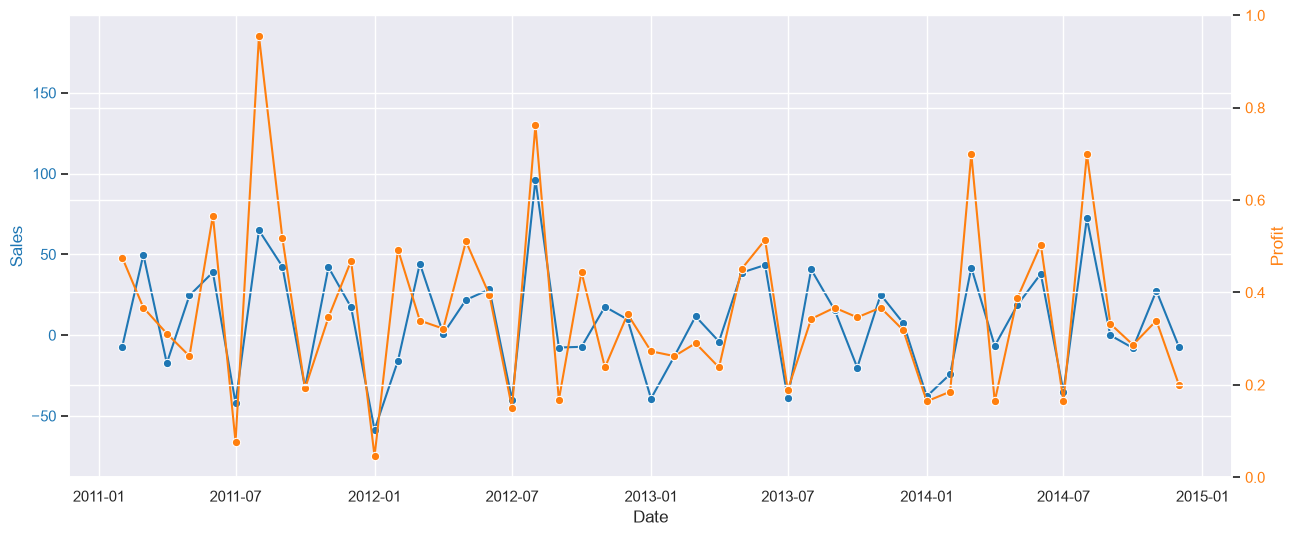

In [65]:
sns.set_theme()

fig, ax1 = plt.subplots(figsize=(15, 6))

sns.lineplot(
    data=monthly_sales_and_profit,
    ax=ax1,
    x='Date',
    y='Sales_MoM_Pct',
    marker='o',
    color='tab:blue'
)
ax1.set_ylabel('Sales', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
sns.lineplot(
    data=monthly_sales_and_profit,
    ax=ax1,
    x='Date',
    y='Profit_MoM_Pct',
    marker='o',
    color='tab:orange'
)
ax2.set_ylabel('Profit', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')


In [ ]:
# Business Question 1:
# What is the overall month-over-month trend for Sales and Profit? Is the business growing?

# Answer:
# Business is not growing but it also shows the company experience the same performance in the past years and able to pull back from gaining.
# Sales and Profits are trending down but also history shows, it would not go down below -50% loss in sales, and lesser than 2% in profit.
# As long as the same business strategy applied based on the past, especially in year 2011 3rd quarter, expect bounce back in the next coming months.